# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `Pillow (PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
import cv2
import numpy as np
from matplotlib import pyplot as plt

(-0.5, 511.5, 511.5, -0.5)

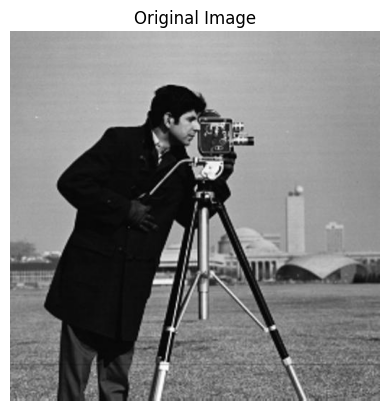

In [2]:
# ── Load image ────────────────────────────────────
img = cv2.imread('cameraman.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [3]:
# Get the size of the image
from PIL import Image

image = Image.open('cameraman.jpg')
width, height = image.size
print("Original size:", width, height)

# scaling factors
new_width = width * 2
new_height = height * 2

Original size: 512 512


(-0.5, 1023.5, 1023.5, -0.5)

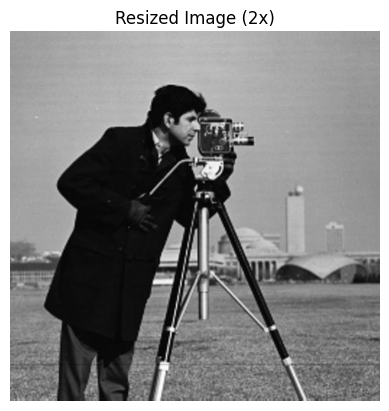

In [6]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
resized_image = image.resize((new_width, new_height), Image.LANCZOS)

plt.imshow(resized_image, cmap='gray')
plt.title("Resized Image (2x)")
plt.axis('off')


In [5]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
resized_image.save("resized_cameraman.jpg")

print("New size:", resized_image.size)

New size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [7]:
#Get size
width, height = image.size
print("Original size:", width, height)

Original size: 512 512


In [8]:
#Apply horizontal strech
new_width = width * 2   # stretch horizontally
new_height = height * 1 # keep same height

stretched = image.resize((new_width, new_height), Image.LANCZOS)

New size: (1024, 512)


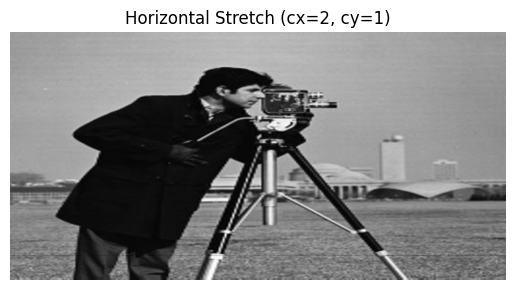

In [9]:
#Display and save
plt.imshow(stretched, cmap='gray')
plt.title("Horizontal Stretch (cx=2, cy=1)")
plt.axis('off')

stretched.save("stretched_cameraman.jpg")
print("New size:", stretched.size)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Rotated size: (700, 700)


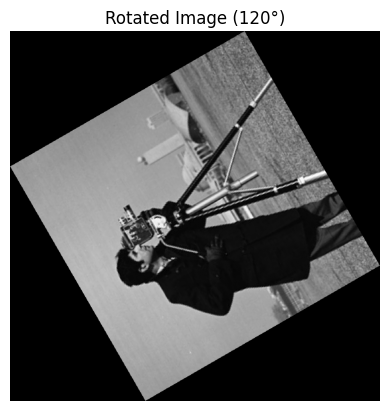

In [10]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
# ── 2. Rotate 120 degrees ──────────────────────────
rotated = image.rotate(120, expand=True)

plt.imshow(rotated, cmap='gray')
plt.title("Rotated Image (120°)")
plt.axis('off')

# Save with required name
rotated.save("task1_2_rotated.jpg")

# Print size
print("Rotated size:", rotated.size)

### 3. Shear

In [11]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size
print("Original size:", width, height)

Original size: 512 512


In [12]:
shear_factor = 0.5

In [ ]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_matrix = (1, shear_factor, 0,
                0, 1, 0)

(-0.5, 767.5, 511.5, -0.5)

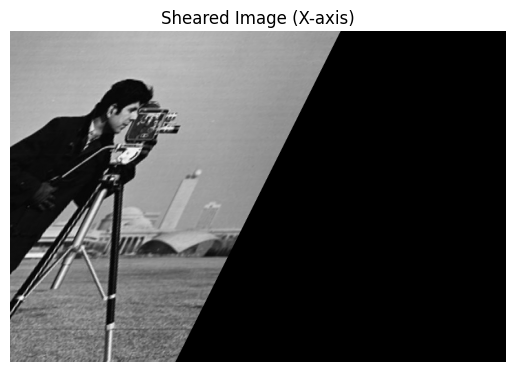

In [13]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
shx = shear_factor   # horizontal shear
shy = 0              # no vertical shear
new_width = width + int(abs(shx) * height)
sheared = image.transform(
    (new_width, height),
    Image.AFFINE,
    (1, shx, 0,
     shy, 1, 0)
)
plt.imshow(sheared, cmap='gray')
plt.title("Sheared Image (X-axis)")
plt.axis('off')

In [14]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared.save("task1_3_sheared.jpg")
print("Sheared size:", sheared.size)

Sheared size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

(-0.5, 511.5, 511.5, -0.5)

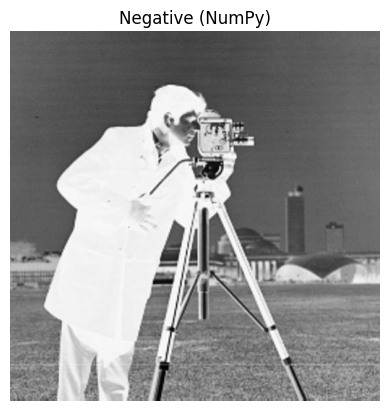

In [15]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
import numpy as np
img_gray = np.array(image)
negative = 255 - img_gray
plt.imshow(negative, cmap='gray')
plt.title("Negative (NumPy)")
plt.axis('off')

(-0.5, 511.5, 511.5, -0.5)

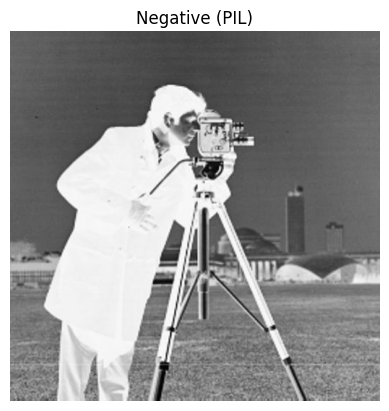

In [16]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

negative_pil = ImageOps.invert(image)

plt.imshow(negative_pil, cmap='gray')
plt.title("Negative (PIL)")
plt.axis('off')

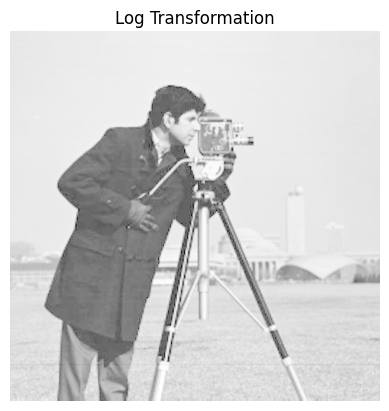

In [17]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)
import numpy as np
from PIL import Image

# Convert image to array (float to avoid errors)
arr = np.array(image).astype(np.float32)

# Compute constant c
c = 255 / np.log(1 + np.max(arr))

# Apply the log transformation to each pixel
log_transformed_arr = c * np.log(1 + arr)

# Convert back to valid image format
log_transformed_arr = np.clip(log_transformed_arr, 0, 255)
log_transformed_arr = np.uint8(log_transformed_arr)

# Convert to image
log_image = Image.fromarray(log_transformed_arr)

# Display
plt.imshow(log_image, cmap='gray')
plt.title("Log Transformation")
plt.axis('off')
plt.show()


In [18]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 2.0

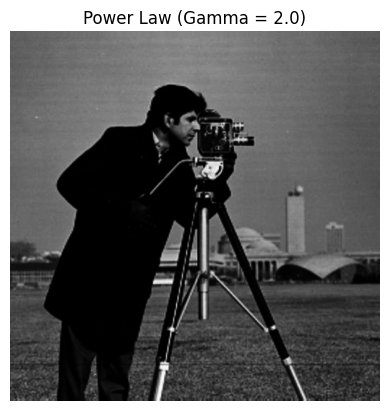

In [19]:
arr = np.array(image).astype(np.float32)

power_arr = 255 * ((arr / 255) ** gamma)

power_arr = np.clip(power_arr, 0, 255)
power_arr = np.uint8(power_arr)

power_image = Image.fromarray(power_arr)

plt.imshow(power_image, cmap='gray')
plt.title(f"Power Law (Gamma = {gamma})")
plt.axis('off')
plt.show()